In [1]:
# Importar librerías necesarias
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree

https://www.kaggle.com/datasets/uciml/adult-census-income/data

In [2]:
# Cargar el conjunto de datos
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
column_names = ['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 
                'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 
                'hours_per_week', 'native_country', 'income']
df = pd.read_csv(
    url,
    header=None, 
    names=column_names, 
    na_values=' ?' # en el dataframe los valores nulos vienen como " ?"
)

In [3]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [4]:
df["income"].unique()

array([' <=50K', ' >50K'], dtype=object)

Descripción de los datos:
* age: Edad del individuo.
* workclass: Categoría de la clase de trabajo a la que pertenece el individuo.
* fnlwgt: Peso final, que representa el número de personas en la población que el individuo representa.
* education: Nivel educativo alcanzado por el individuo.
* education_num: Número asociado al nivel educativo del individuo.
* marital_status: Estado civil del individuo.
* occupation: Ocupación del individuo.
* relationship: Relación del individuo con el jefe de hogar.
* race: Raza del individuo.
* sex: Sexo del individuo.
* capital_gain: Ganancia de capital obtenida.
* capital_loss: Pérdida de capital incurrida.
* hours_per_week: Número de horas trabajadas por semana.
* native_country: País de origen del individuo.
* income: Ingreso del individuo (si es mayor o menor que 50K al año).

In [5]:
(df.isnull().sum() / df.shape[0] * 100).round(1)

age               0.0
workclass         5.6
fnlwgt            0.0
education         0.0
education_num     0.0
marital_status    0.0
occupation        5.7
relationship      0.0
race              0.0
sex               0.0
capital_gain      0.0
capital_loss      0.0
hours_per_week    0.0
native_country    1.8
income            0.0
dtype: float64

<Figure size 1600x500 with 0 Axes>

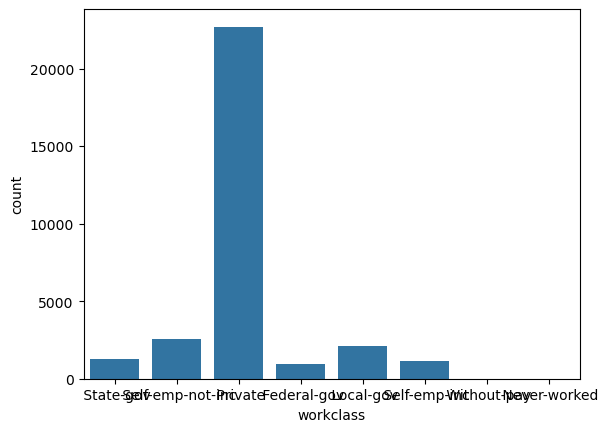

<Figure size 1600x500 with 0 Axes>

In [6]:
sns.countplot(x = df["workclass"])
plt.figure(figsize = (16,5))

In [7]:
valor = df.workclass.mode()[0]
df.workclass = df.workclass.fillna(valor)

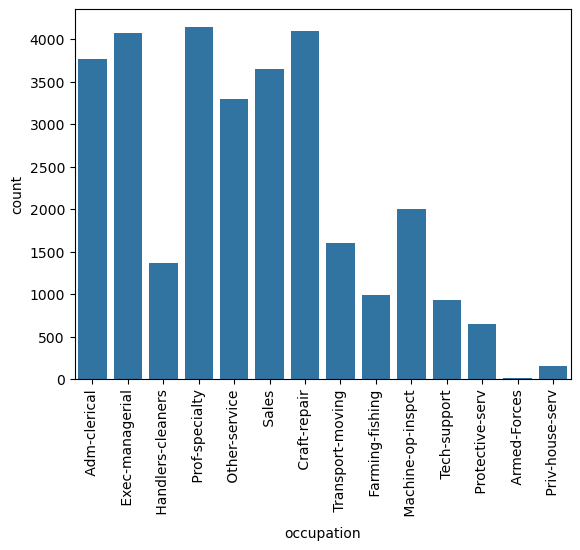

In [8]:
sns.countplot(x = df["occupation"])
plt.xticks(rotation = 90)
plt.show()

In [9]:
df.occupation = df.occupation.fillna("Others")

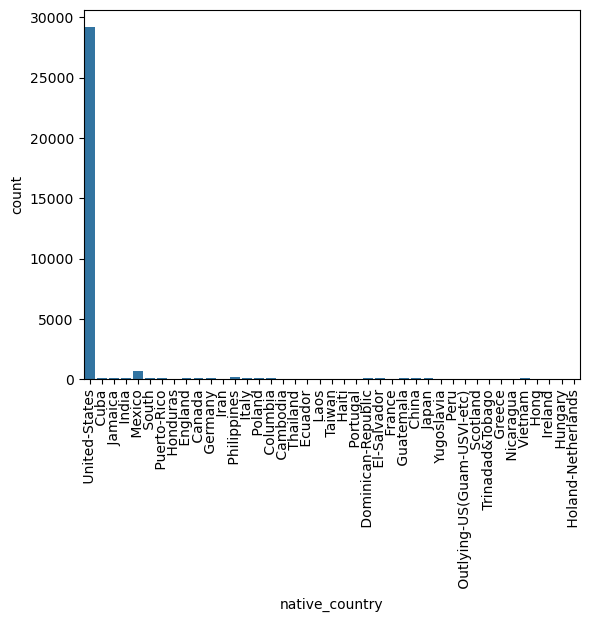

In [10]:
sns.countplot(x = df["native_country"])
plt.xticks(rotation = 90)
plt.show()

In [11]:
valor = df.native_country.mode()[0]
df.native_country = df.native_country.fillna(valor)

In [12]:
(df.isnull().sum() / df.shape[0] * 100).round(1)

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education_num     0.0
marital_status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital_gain      0.0
capital_loss      0.0
hours_per_week    0.0
native_country    0.0
income            0.0
dtype: float64

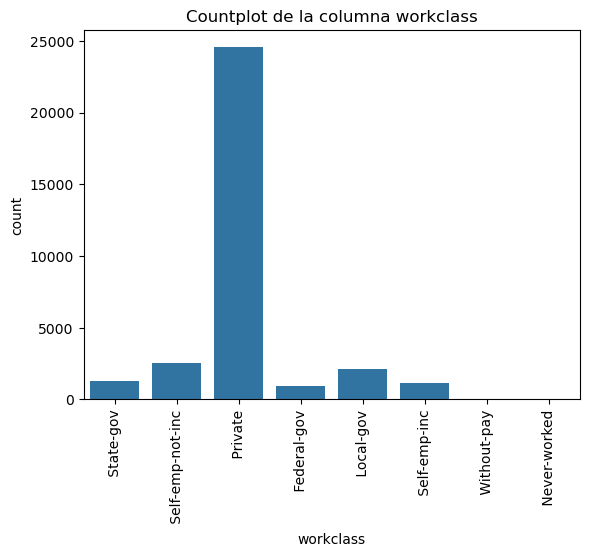

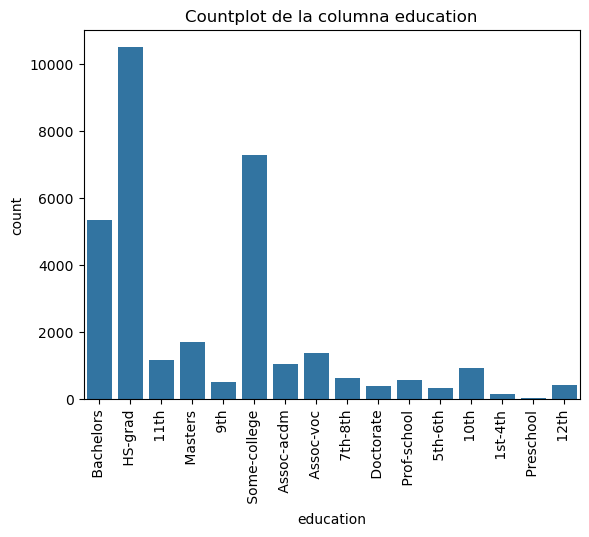

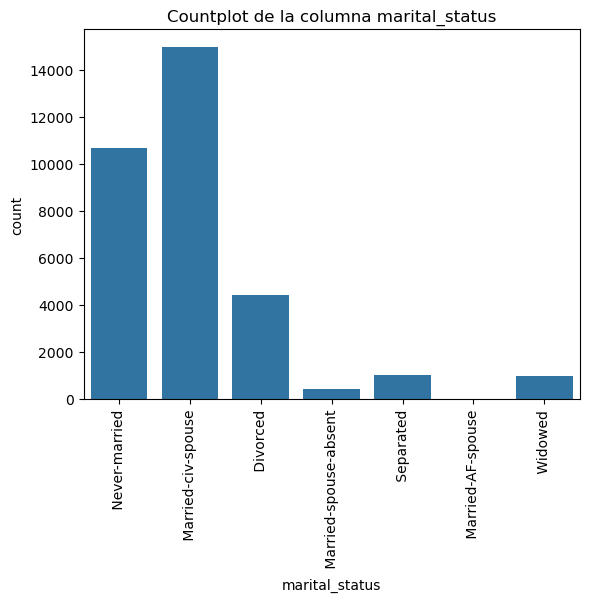

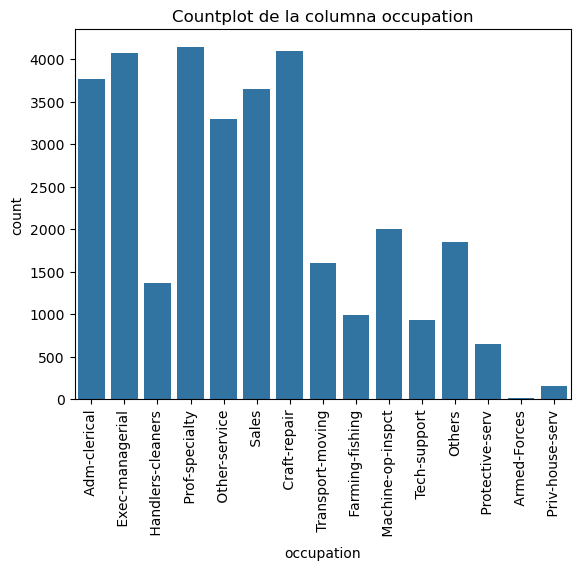

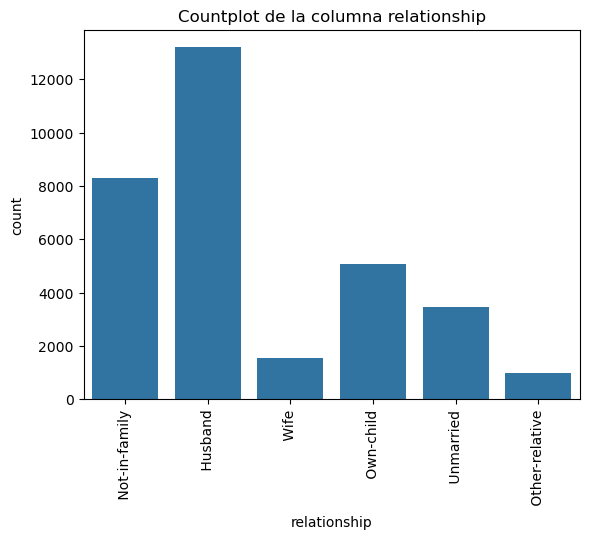

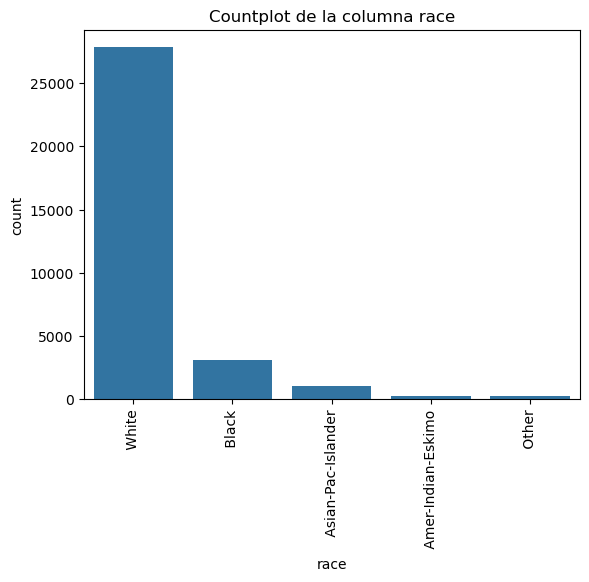

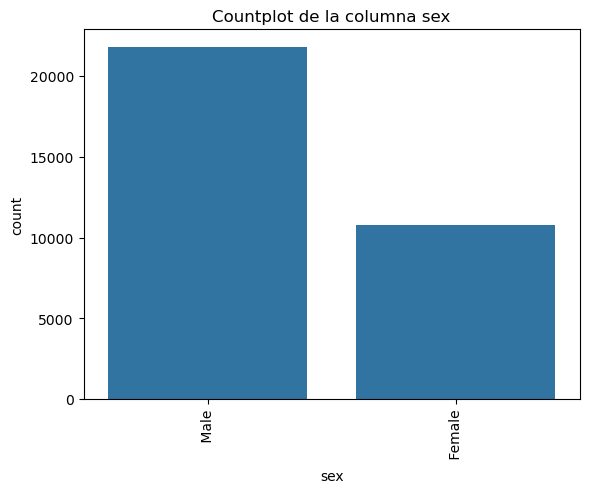

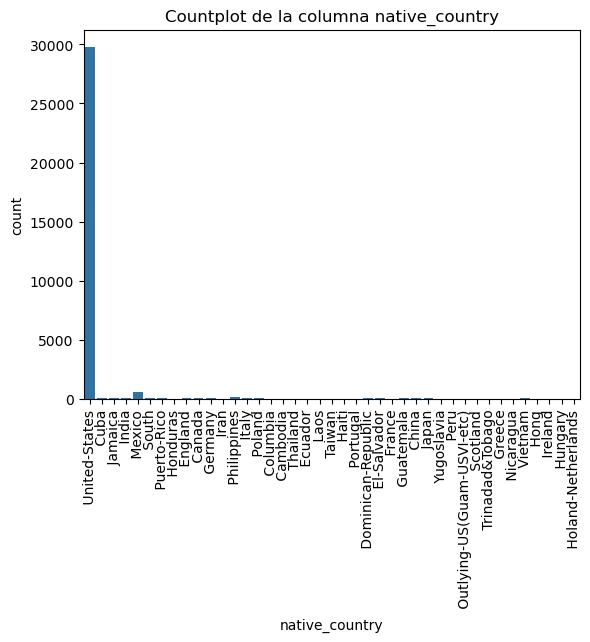

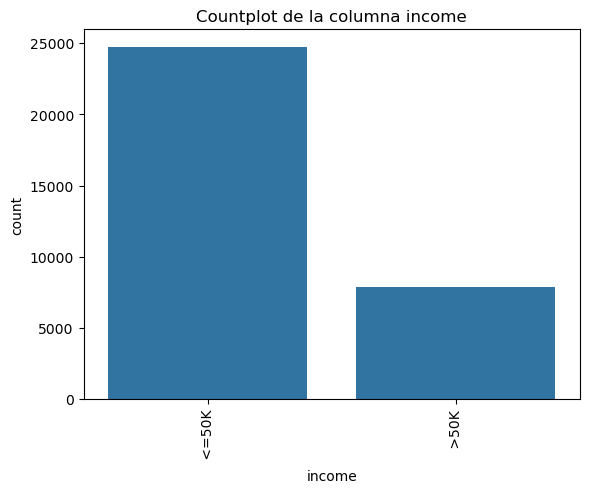

In [13]:
filtro = df.dtypes == "object"
df.columns[filtro]

for columna in df.columns[filtro]:
    sns.countplot(data = df, x = columna)
    plt.xticks(rotation = 90)
    plt.title(f"Countplot de la columna {columna}")
    plt.show()

In [14]:
df["income"] = df["income"].str.strip()

In [15]:
df.income = df.income.replace({
    "<=50K": 0,
    ">50K": 1
})

C:\Users\Dalp-\AppData\Local\Temp\ipykernel_11480\2979087356.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.income = df.income.replace({


In [16]:
df["sex"] = df["sex"].str.strip()

df.sex = df.sex.replace({
    "Male": 0,
    "Female": 1
})

C:\Users\Dalp-\AppData\Local\Temp\ipykernel_11480\1679488502.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.sex = df.sex.replace({


In [17]:
df["education"].unique()

array([' Bachelors', ' HS-grad', ' 11th', ' Masters', ' 9th',
       ' Some-college', ' Assoc-acdm', ' Assoc-voc', ' 7th-8th',
       ' Doctorate', ' Prof-school', ' 5th-6th', ' 10th', ' 1st-4th',
       ' Preschool', ' 12th'], dtype=object)

In [18]:
df["education"] = df["education"].str.strip()

In [19]:
mapeo_educacion = {
    'Preschool': 'Primaria o Menos', '1st-4th': 'Primaria o Menos', '5th-6th': 'Primaria o Menos',
    '7th-8th': 'Secundaria Incompleta', '9th': 'Secundaria Incompleta', '10th': 'Secundaria Incompleta', 
    '11th': 'Secundaria Incompleta', '12th': 'Secundaria Incompleta',
    'HS-grad': 'Secundaria Completa',
    'Some-college': 'Educación Técnica/Universitaria Incompleta', 'Assoc-acdm': 'Educación Técnica/Universitaria Incompleta', 
    'Assoc-voc': 'Educación Técnica/Universitaria Incompleta',
    'Bachelors': 'Grado Universitario o Superior', 'Masters': 'Grado Universitario o Superior', 
    'Prof-school': 'Grado Universitario o Superior', 'Doctorate': 'Grado Universitario o Superior'
}

df["education"] = df["education"].replace(mapeo_educacion)

In [20]:
df.head()

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Grado Universitario o Superior,13,Never-married,Adm-clerical,Not-in-family,White,0,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Grado Universitario o Superior,13,Married-civ-spouse,Exec-managerial,Husband,White,0,0,0,13,United-States,0
2,38,Private,215646,Secundaria Completa,9,Divorced,Handlers-cleaners,Not-in-family,White,0,0,0,40,United-States,0
3,53,Private,234721,Secundaria Incompleta,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,0,0,0,40,United-States,0
4,28,Private,338409,Grado Universitario o Superior,13,Married-civ-spouse,Prof-specialty,Wife,Black,1,0,0,40,Cuba,0


In [21]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [22]:
df.drop(columns = "education_num", inplace = True)

In [23]:
df.head()

,age,workclass,fnlwgt,education,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Grado Universitario o Superior,Never-married,Adm-clerical,Not-in-family,White,0,2174,0,40,United-States,0
1,50,Self-emp-not-inc,83311,Grado Universitario o Superior,Married-civ-spouse,Exec-managerial,Husband,White,0,0,0,13,United-States,0
2,38,Private,215646,Secundaria Completa,Divorced,Handlers-cleaners,Not-in-family,White,0,0,0,40,United-States,0
3,53,Private,234721,Secundaria Incompleta,Married-civ-spouse,Handlers-cleaners,Husband,Black,0,0,0,40,United-States,0
4,28,Private,338409,Grado Universitario o Superior,Married-civ-spouse,Prof-specialty,Wife,Black,1,0,0,40,Cuba,0


In [24]:
df["relationship"] = df["relationship"].str.strip()

In [25]:
mapeo_relationship = {
    'Wife': 'Esposo/Esposa', 
    'Husband': 'Esposo/Esposa',
    'Own-child': 'Hijo',
    'Other-relative': 'Otro Pariente',
    'Not-in-family': 'No en Familia',
    'Unmarried': 'No en Familia'
}

df["relationship"] = df["relationship"].replace(mapeo_relationship)

In [26]:
df["marital_status"] = df["marital_status"].str.strip()

In [27]:
mapeo_marital_status = {
    'Married-civ-spouse': 'Casado',
    'Married-spouse-absent': 'Casado', 
    'Married-AF-spouse': 'Casado',
    'Never-married': 'No Casado',
    'Divorced': 'Separado/Divorciado/Viudo', 
    'Separated': 'Separado/Divorciado/Viudo',
    'Widowed': 'Separado/Divorciado/Viudo'
}

df["marital_status"] = df["marital_status"].replace(mapeo_marital_status)

In [28]:
df["native_country"] = np.where(df["native_country"] == " United-States", "United-States", "Other")

In [29]:
df["native_country"].unique()

array(['United-States', 'Other'], dtype=object)

In [30]:
df["workclass"] = df["workclass"].str.strip()

In [31]:
mapeo_workclass = {
    'Private': 'Privado',
    'Self-emp-not-inc': 'Autónomo', 
    'Self-emp-inc': 'Autónomo',
    'Federal-gov': 'Gobierno',
    'Local-gov': 'Gobierno', 
    'State-gov': 'Gobierno',
    'Without-pay': 'Sin Pago/No Trabajado',
    'Never-worked': 'Sin Pago/No Trabajado'
}

df["workclass"] = df["workclass"].replace(mapeo_workclass)

In [32]:
df.head()

,age,workclass,fnlwgt,education,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,Gobierno,77516,Grado Universitario o Superior,No Casado,Adm-clerical,No en Familia,White,0,2174,0,40,United-States,0
1,50,Autónomo,83311,Grado Universitario o Superior,Casado,Exec-managerial,Esposo/Esposa,White,0,0,0,13,United-States,0
2,38,Privado,215646,Secundaria Completa,Separado/Divorciado/Viudo,Handlers-cleaners,No en Familia,White,0,0,0,40,United-States,0
3,53,Privado,234721,Secundaria Incompleta,Casado,Handlers-cleaners,Esposo/Esposa,Black,0,0,0,40,United-States,0
4,28,Privado,338409,Grado Universitario o Superior,Casado,Prof-specialty,Esposo/Esposa,Black,1,0,0,40,Other,0


In [33]:
df.isnull().sum()

age               0
workclass         0
fnlwgt            0
education         0
marital_status    0
occupation        0
relationship      0
race              0
sex               0
capital_gain      0
capital_loss      0
hours_per_week    0
native_country    0
income            0
dtype: int64

In [34]:
df = pd.get_dummies(
    df,
    columns = ["workclass", "education", "marital_status", "occupation",
               "relationship", "race", "native_country"],
    drop_first = True
)

In [35]:
df.head()

,age,fnlwgt,sex,capital_gain,capital_loss,hours_per_week,income,workclass_Gobierno,workclass_Privado,workclass_Sin Pago/No Trabajado,...,occupation_ Transport-moving,occupation_Others,relationship_Hijo,relationship_No en Familia,relationship_Otro Pariente,race_ Asian-Pac-Islander,race_ Black,race_ Other,race_ White,native_country_United-States
0,39,77516,0,2174,0,40,0,True,False,False,...,False,False,False,True,False,False,False,False,True,True
1,50,83311,0,0,0,13,0,False,False,False,...,False,False,False,False,False,False,False,False,True,True
2,38,215646,0,0,0,40,0,False,True,False,...,False,False,False,True,False,False,False,False,True,True
3,53,234721,0,0,0,40,0,False,True,False,...,False,False,False,False,False,False,True,False,False,True
4,28,338409,1,0,0,40,0,False,True,False,...,False,False,False,False,False,False,True,False,False,False


In [36]:
X = df.drop(columns="income")
y = df["income"]

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    train_size = 0.75,
    test_size = 0.25,
)

In [38]:
X_train.shape

(24420, 37)

In [39]:
X_test.shape

(8141, 37)

In [40]:
modelo = DecisionTreeClassifier(max_depth = 9)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)

accuracy_score(y_test, y_pred)

0.8581255374032674

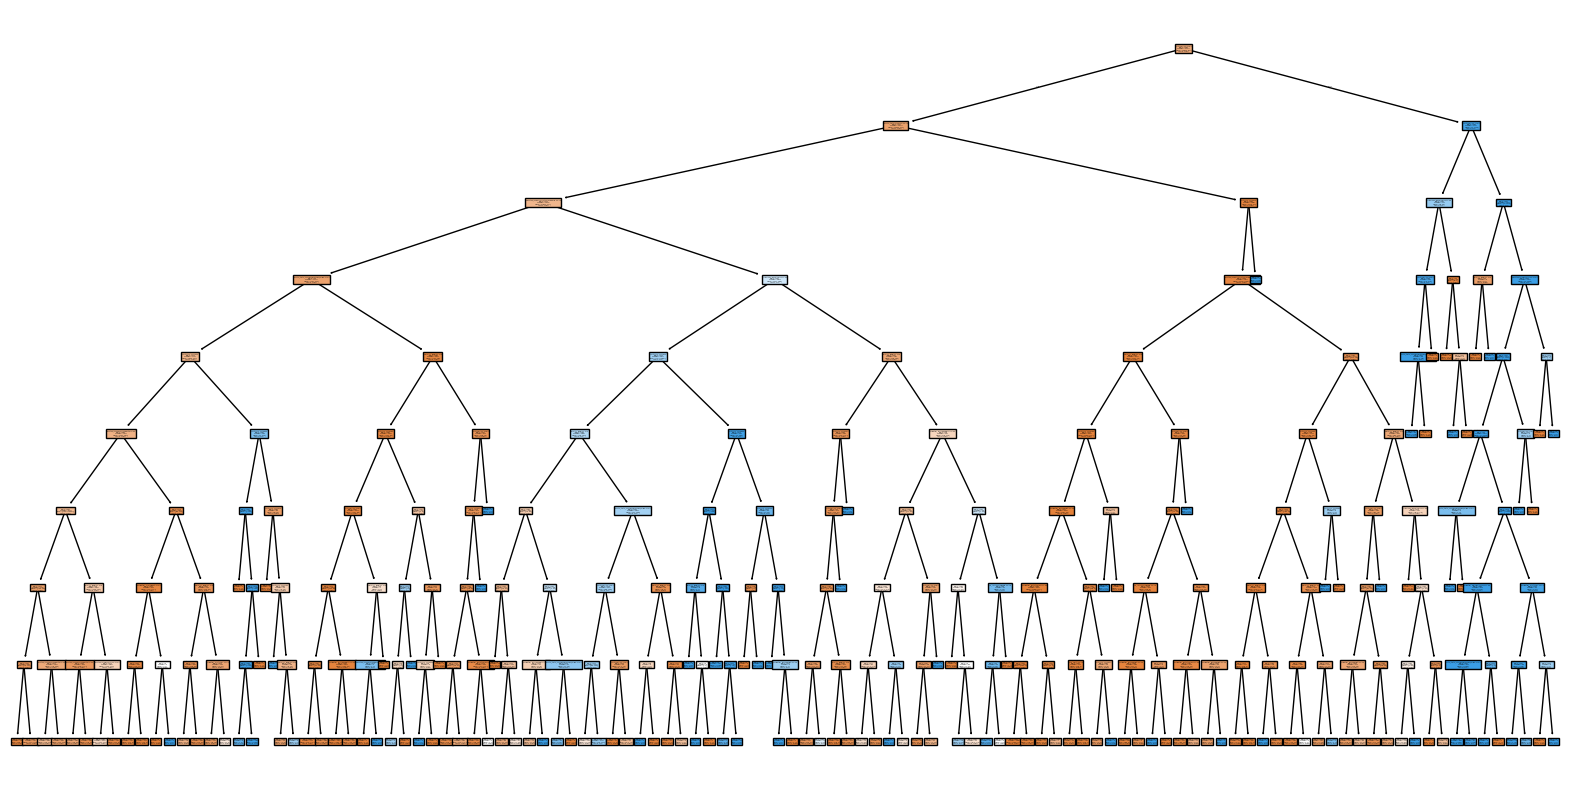

In [41]:
plt.figure(figsize=(20,10))
tree.plot_tree(
    modelo,
    feature_names=X.columns,
    class_names=["<=50K", ">50K"],
    filled=True,
    max_depth = 9
)
plt.show()

In [42]:
modelo = RandomForestClassifier(max_depth=19, n_estimators = 200)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
accuracy_score(y_test, y_pred)

0.866601154649306